In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('spam.csv',encoding='ISO-8859-1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [5]:
df=df[["v1","v2"]]

In [6]:
df.rename(columns={'v1':'target','v2':'msg'},inplace=True)

In [7]:
df["target"]=df["target"].map({"ham":0,"spam":1})

In [8]:
# data cleaning -> EDA -> text preprocessing -> model building -> evaluation -> improvement -> website -> deploy

In [9]:
#check for duplicated values
df.duplicated().sum()

403

In [10]:
df.drop_duplicates(keep="first",inplace=True)

In [11]:
df.shape

(5169, 2)

In [12]:
#now EDA 

In [13]:
df["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

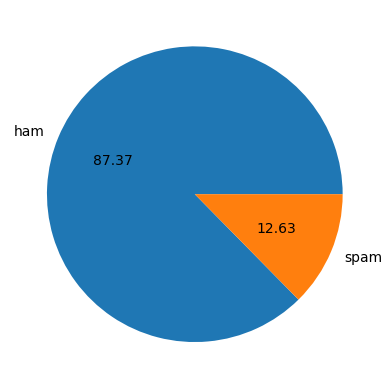

In [14]:
import matplotlib.pyplot as plt
plt.pie(df["target"].value_counts(), labels=["ham","spam"],autopct="%0.2f")
plt.show() #data is imbalanced

In [15]:
import nltk

In [16]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\astit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\astit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [17]:
df["num_chars"]=df['msg'].apply(len)

In [18]:
#for num of words
df["num_words"]=df['msg'].apply(lambda x:len(nltk.word_tokenize(x)))

In [19]:
df["num_sents"]=df['msg'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [20]:
df.head(1000)

,target,msg,num_chars,num_words,num_sents
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
1019,0,Don know..wait i will check it.,31,9,1
1020,0,Good afternoon on this glorious anniversary da...,224,46,4
1021,1,Guess what! Somebody you know secretly fancies...,156,29,4
1022,0,We still on for tonight?,24,6,1


In [21]:
#for ham msgs
df[df["target"]==0][["num_chars","num_words","num_sents"]].describe()

,num_chars,num_words,num_sents
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [22]:
#for spam msgs
df[df["target"]==1][["num_chars","num_words","num_sents"]].describe()

,num_chars,num_words,num_sents
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [23]:
!pip install seaborn
import seaborn as sns

<Axes: xlabel='num_chars', ylabel='Count'>

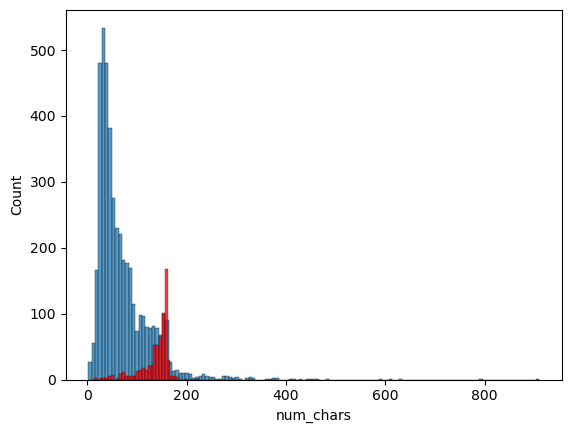

In [24]:
sns.histplot(df[df["target"]==0]["num_chars"])
sns.histplot(df[df["target"]==1]["num_chars"], color="red")

<Axes: xlabel='num_words', ylabel='Count'>

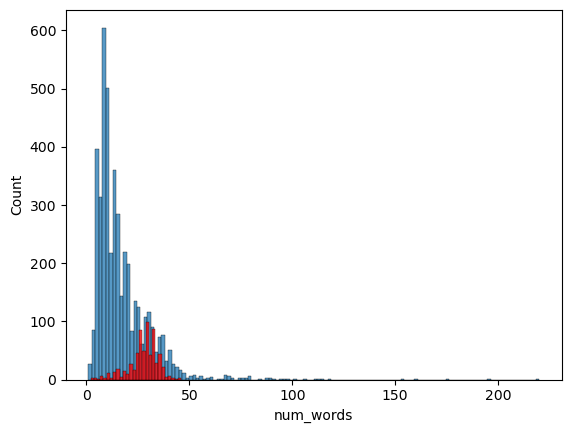

In [25]:
sns.histplot(df[df["target"]==0]["num_words"])
sns.histplot(df[df["target"]==1]["num_words"], color="red")

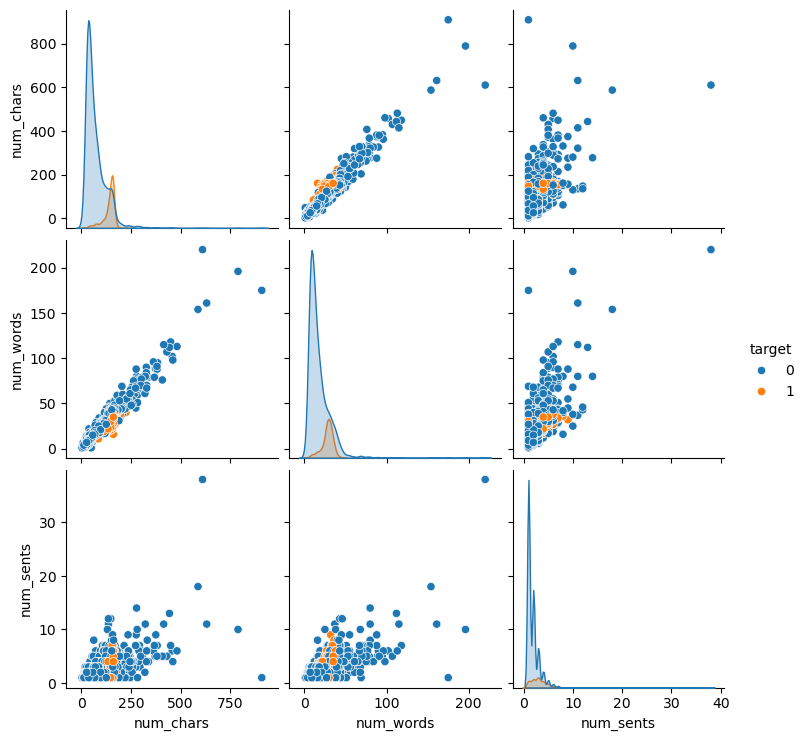

In [26]:
sns.pairplot(df,hue="target")

<Axes: >

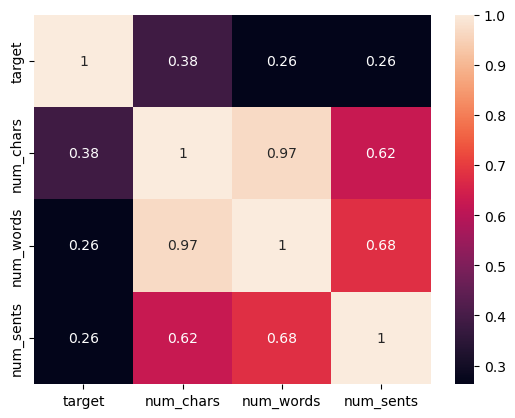

In [27]:
sns.heatmap(df[["target","num_chars","num_words","num_sents"]].corr(),annot=True)

In [28]:
#now data preprocessing
# involves : lowercase (already done) -> tokenization removing special characters -> remove stop words and punctuation -> stemming

#for stop words
nltk.download('stopwords')
from nltk.corpus import stopwords
#stopwords.words('english') -> this will give all the words used in sentence formation -> no use for us

#for punctuation
import string
string.punctuation

#for stemming
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\astit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    r=[]
    for i in text:
        if i.isalnum():
            r+=[i]

    text=r[:]
    r.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            r.append(i)

    text=r[:]
    r.clear()
    for i in text:
        r.append(ps.stem(i))
        
    return " ".join(r)

In [30]:
transform_text("did youH liking  ?")

'youh like'

In [32]:
from tqdm import tqdm
tqdm.pandas()

df['transformed_text'] = df['msg'].progress_apply(transform_text)

100%|██████████████████████████████████████████████████████████████████████████████| 5169/5169 [05:46<00:00, 14.92it/s]


In [33]:
df.head()

,target,msg,num_chars,num_words,num_sents,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [38]:
#now generating word cloud that shows the most imp words in big form
!pip install wordcloud
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [39]:
spam_wc=wc.generate(df[df["target"]==1]['transformed_text'].str.cat(sep=" "))

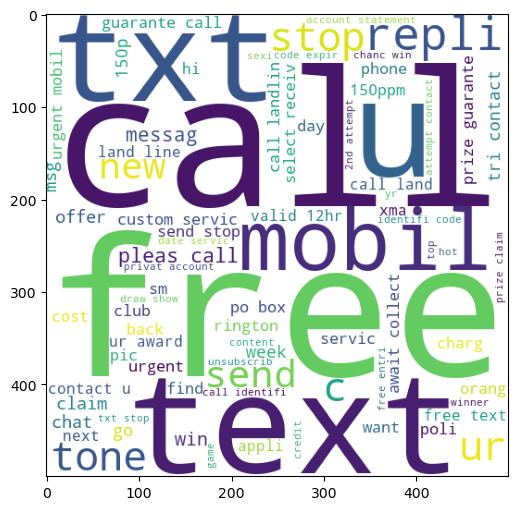

In [40]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

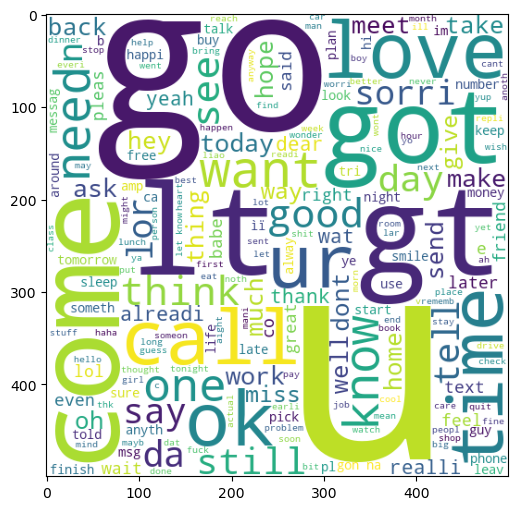

In [41]:
ham_wc=wc.generate(df[df["target"]==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [42]:
df.head()

,target,msg,num_chars,num_words,num_sents,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [43]:
spam_corpus=[]
for text in df[df["target"]==1]["transformed_text"].tolist():
    for word in text.split():
        spam_corpus+=[word]
    

In [45]:
len(spam_corpus)

9939

In [47]:
#now to check which word is repeated how many times
from collections import Counter

In [48]:
Counter(spam_corpus)

Counter({'call': 320,
         'free': 191,
         '2': 155,
         'txt': 141,
         'text': 122,
         'u': 119,
         'ur': 119,
         'mobil': 114,
         'stop': 104,
         'repli': 103,
         'claim': 98,
         '4': 97,
         'prize': 82,
         'get': 74,
         'new': 64,
         'servic': 64,
         'tone': 63,
         'send': 60,
         'urgent': 57,
         'nokia': 57,
         'contact': 56,
         'award': 55,
         'phone': 52,
         'cash': 51,
         'pleas': 51,
         'week': 49,
         'win': 48,
         'c': 45,
         'collect': 45,
         'min': 45,
         'custom': 42,
         'messag': 42,
         'guarante': 42,
         'per': 41,
         'chat': 38,
         'tri': 37,
         'msg': 35,
         'draw': 35,
         'number': 35,
         'cs': 35,
         'show': 33,
         'today': 33,
         'offer': 33,
         'line': 33,
         'go': 32,
         'receiv': 31,
         'want': 3

In [49]:
Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

In [50]:
#similarly we can do for ham msgs

In [51]:
#model building
#we will use naive bayes -> general thing that it works well with textual data -> top priority is precision here

In [134]:
#text vectorization -> here we will use bag of words
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [135]:
#X=cv.fit_transform(df['transformed_text']).toarray()
X=tfidf.fit_transform(df['transformed_text']).toarray()

In [136]:
#appending the num_chars,num_words,num_sents cols to X
#X=np.hstack((X,df['num_chars'].values.reshape(-1,1))) -> also reduced the accuracy although precision remained 1.0

In [137]:
#now we can scale -> chances are there that performance improves

#'''
#from sklearn.preprocessing import MinMaxScaler
#scaler=MinMaxScaler()
#X=scaler.fit_transform(X)
#'''

#this improved accuracy for mnb but decreased the precision alot

In [138]:
X.shape

(5169, 3000)

In [139]:
y=df['target'].values

In [140]:
y

array([0, 0, 1, ..., 0, 0, 0], dtype=int64)

In [141]:
from sklearn.model_selection import train_test_split

In [142]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [143]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [144]:
gnb,mnb,bnb=GaussianNB(),MultinomialNB(),BernoulliNB()

In [145]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8694390715667312
[[788 108]
 [ 27 111]]
0.5068493150684932


In [146]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

#best one till now

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [147]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [148]:
#so we will go by tfidf -> mnb , voting classifiers and stacking also not that good as mnb in precision

In [149]:
import pickle 
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))